<a href="https://colab.research.google.com/github/JyRaGa/CS303-Machine-Learning_Coursework/blob/main/exp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS303 Machine Learning Lab
## Experiment No. 09: Support Vector Machines and Kernel Effects
### Roll No: 24/CS/232

---

### **Aim:**
To implement a Support Vector Machine (SVM) classifier and study the effect of the regularisation parameter $C$ and RBF kernel parameter $\gamma$ on the decision boundary, margin, support vectors, underfitting, and overfitting.

### **Objectives:**
After completing this experiment, students will be able to:
1. Understand the concept of a **maximum-margin classifier**.
2. Implement a **linear-kernel SVM** using `SVC`.
3. Visualize the SVM **decision boundary** using two features.
4. Study the effect of different values of **$C$**.
5. Understand the concept of **soft margin** and misclassification tolerance.
6. Implement an SVM with an **RBF kernel**.
7. Study the effect of different values of **$\gamma$**.
8. Identify **underfitting and overfitting** from decision-boundary plots.
9. Compare **linear and nonlinear** decision boundaries.
10. Select a suitable combination of **kernel, $C$, and $\gamma$**.

### **Pseudo Algorithm / Steps:**
1. **Start**
2. **Load** the binary classification dataset (Breast Cancer Wisconsin).
3. **Select** two numerical features for visualization.
4. **Separate** the features $X$ and target $y$.
5. **Split** the dataset into training and testing sets.
6. **Standardize** the selected features because SVM is sensitive to feature scale.
7. **Train** an SVM using a linear kernel with $C = 1$.
8. **Generate** a 2-D mesh over the feature space.
9. **Predict** the class of each point in the mesh and visualize the decision boundary.
10. **Train** linear SVM models using $C = 0.01, 1, 100$ and compare decision boundaries, number of support vectors, and training/test performance.
11. **Replace** the linear kernel with an RBF kernel.
12. **Train** models using $\gamma = 0.01, 0.1, 1, 10$.
13. **Visualize** the resulting decision boundaries.
14. **Identify** configurations showing underfitting, reasonable fit and overfitting.
15. **Select** a suitable kernel and hyperparameter combination based on the observed results.
16. **Stop**

**1. Loading the Dataset & Selecting Features (Steps 1–4)**

* **Dataset:** Breast Cancer Wisconsin (Diagnostic) dataset — the same UCI data hosted on Kaggle, loaded as a DataFrame via `load_breast_cancer(as_frame=True)`.
* **Target Variable ($y$):** Diagnosis — `0 = malignant`, `1 = benign` (Binary Classification Task).
* **Selected Features ($X$):** `mean radius` and `mean texture` — two numerical features so that the decision boundary can be drawn in 2-D.

In [1]:
# import required libraries
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
warnings.filterwarnings('ignore')

# load breast cancer wisconsin dataset as a dataframe (same as kaggle with as_frame toggled)
data = load_breast_cancer(as_frame=True)
df = data.frame
print(f'dataset shape: {df.shape}')
print('\nclass distribution (0 = malignant, 1 = benign):')
print(df['target'].value_counts())

# select two numerical features for 2-d visualization
features = ['mean radius', 'mean texture']
X = df[features].values
y = df['target'].values
df[features + ['target']].head()

dataset shape: (569, 31)

class distribution (0 = malignant, 1 = benign):
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,target
0,17.99,10.38,0
1,20.57,17.77,0
2,19.69,21.25,0
3,11.42,20.38,0
4,20.29,14.34,0


**2. Train-Test Split & Feature Standardization (Steps 5–6)**

* **Dataset Partitioning:** **80% Training** / **20% Testing** with `stratify=y` to preserve the class ratio and `random_state=42` for reproducibility.
* **Standardization:** SVM maximises a geometric margin, so a feature with a larger numeric range would dominate the distance calculations. `StandardScaler` is fit **only on the training set** (to avoid data leakage) and rescales each feature to zero mean and unit variance.

In [2]:
# train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# standardize features using training statistics only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'training set shape: {X_train_s.shape}, testing set shape: {X_test_s.shape}')
print(f'train feature means after scaling: {X_train_s.mean(axis=0).round(4)}')
print(f'train feature stds after scaling : {X_train_s.std(axis=0).round(4)}')

training set shape: (455, 2), testing set shape: (114, 2)
train feature means after scaling: [-0.  0.]
train feature stds after scaling : [1. 1.]


**3. Linear SVM with $C = 1$ & Decision Boundary Visualization (Steps 7–9)**

* **Model:** `SVC(kernel='linear', C=1)` finds the hyperplane $w^T x + b = 0$ that maximises the margin $2 / \lVert w \rVert$.
* **Mesh Grid:** A dense 2-D mesh is generated over the scaled feature space and every mesh point is classified to colour the decision regions.
* **Plot Elements:** solid line = decision boundary ($f(x)=0$), dashed lines = margins ($f(x)=\pm1$), circled points = support vectors.

LINEAR SVM (C = 1)
weights w           : [-2.2975 -0.5257]
bias b              : 0.5188
margin width 2/||w||: 0.8486
support vectors     : 127 (per class: [64 63])
train accuracy      : 0.8967
test accuracy       : 0.8684


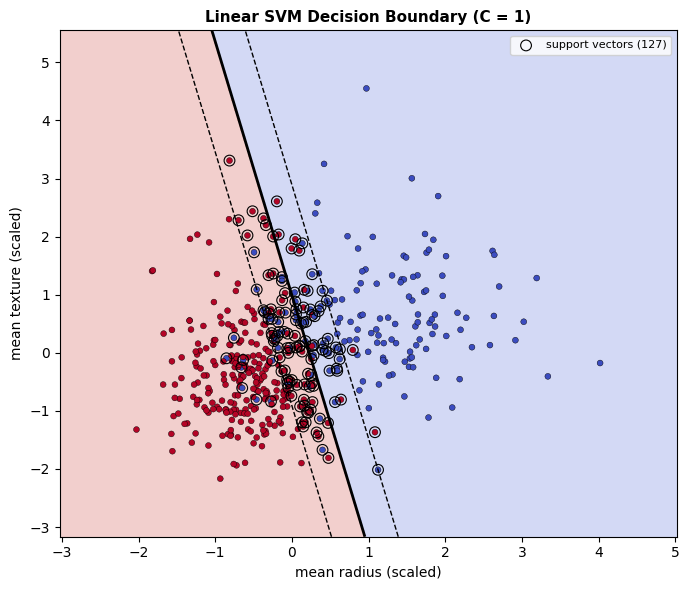

In [3]:
# create a 2-d mesh over the scaled feature space
x_min, x_max = X_train_s[:, 0].min() - 1, X_train_s[:, 0].max() + 1
y_min, y_max = X_train_s[:, 1].min() - 1, X_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

def plot_boundary(model, ax, title):
    # predict class of each mesh point and draw decision regions
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    # decision boundary (0) and margins (-1, +1)
    F = model.decision_function(grid).reshape(xx.shape)
    ax.contour(xx, yy, F, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
    ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=18, edgecolors='k', linewidths=0.3)
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=60, facecolors='none', edgecolors='black', linewidths=0.8, label=f'support vectors ({len(sv)})')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('mean radius (scaled)')
    ax.set_ylabel('mean texture (scaled)')
    ax.legend(loc='upper right', fontsize=8)

# train linear svm with c = 1
linear_svm = SVC(kernel='linear', C=1)
linear_svm.fit(X_train_s, y_train)

train_acc = accuracy_score(y_train, linear_svm.predict(X_train_s))
test_acc = accuracy_score(y_test, linear_svm.predict(X_test_s))
w = linear_svm.coef_[0]
print('=' * 50)
print('LINEAR SVM (C = 1)')
print('=' * 50)
print(f'weights w           : {w.round(4)}')
print(f'bias b              : {linear_svm.intercept_[0]:.4f}')
print(f'margin width 2/||w||: {2 / np.linalg.norm(w):.4f}')
print(f'support vectors     : {linear_svm.n_support_.sum()} (per class: {linear_svm.n_support_})')
print(f'train accuracy      : {train_acc:.4f}')
print(f'test accuracy       : {test_acc:.4f}')
print('=' * 50)

fig, ax = plt.subplots(figsize=(7, 6))
plot_boundary(linear_svm, ax, 'Linear SVM Decision Boundary (C = 1)')
plt.tight_layout()
plt.show()

**4. Effect of $C$ on the Linear SVM — Soft Margin (Step 10)**

* **Soft-Margin Objective:** $\min_{w,b,\xi} \frac{1}{2}\lVert w \rVert^2 + C \sum_i \xi_i$, where the slack $\xi_i$ measures how much point $i$ violates the margin.
* **Small $C$:** violations are cheap → wider margin, more support vectors, simpler boundary.
* **Large $C$:** violations are expensive → narrower margin, fewer support vectors, stricter classification of training points.

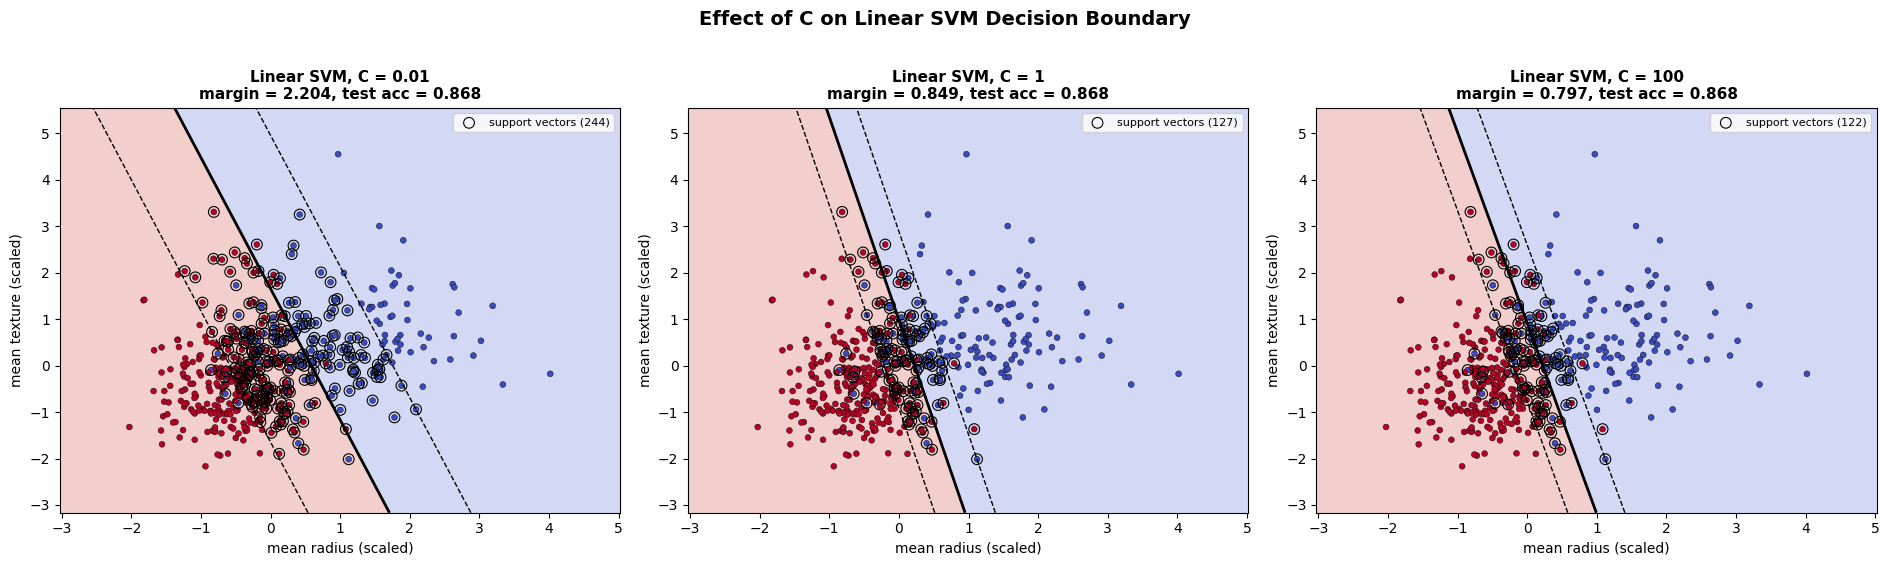

Kernel      C Gamma  Train Accuracy  Test Accuracy  No. of Support Vectors  Margin Width
Linear   0.01     -          0.8637         0.8684                     244        2.2042
Linear   1.00     -          0.8967         0.8684                     127        0.8486
Linear 100.00     -          0.8967         0.8684                     122        0.7968


In [4]:
# train linear svm models with different c values
results = []
C_values = [0.01, 1, 100]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for ax, C in zip(axes, C_values):
    model = SVC(kernel='linear', C=C).fit(X_train_s, y_train)
    tr = accuracy_score(y_train, model.predict(X_train_s))
    te = accuracy_score(y_test, model.predict(X_test_s))
    margin = 2 / np.linalg.norm(model.coef_[0])
    results.append({'Kernel': 'Linear', 'C': C, 'Gamma': '-', 'Train Accuracy': tr, 'Test Accuracy': te,
                    'No. of Support Vectors': model.n_support_.sum(), 'Margin Width': margin})
    plot_boundary(model, ax, f'Linear SVM, C = {C}\nmargin = {margin:.3f}, test acc = {te:.3f}')

plt.suptitle('Effect of C on Linear SVM Decision Boundary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(pd.DataFrame(results).round(4).to_string(index=False))

**5. RBF Kernel SVM & Effect of $\gamma$ (Steps 11–13)**

* **RBF Kernel:** $K(x, x') = \exp(-\gamma \lVert x - x' \rVert^2)$ implicitly maps the data into an infinite-dimensional space, giving a **nonlinear** boundary in the original 2-D space.
* **$\gamma$ controls the reach of each training point:** small $\gamma$ → each point influences a wide region (smooth boundary); large $\gamma$ → influence is very local (wiggly boundary that wraps individual points).
* $C = 1$ is kept fixed so that only the effect of $\gamma$ is observed.

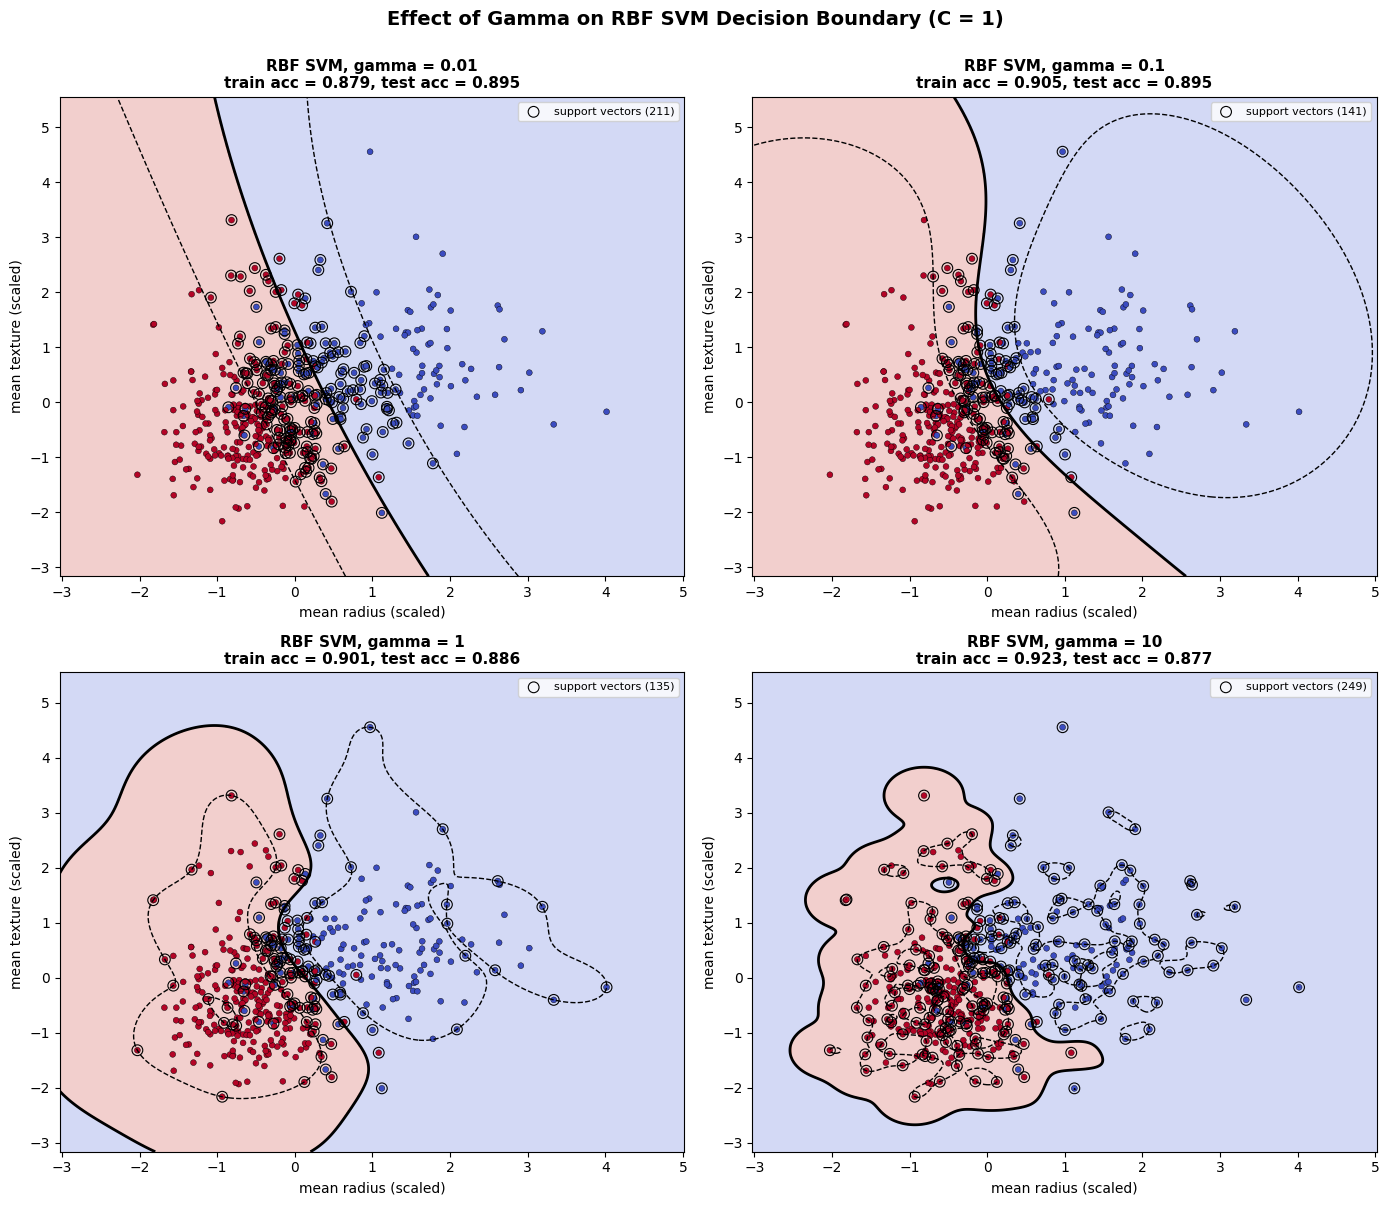

In [5]:
# train rbf svm models with different gamma values (c fixed at 1)
gamma_values = [0.01, 0.1, 1, 10]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, g in zip(axes.flatten(), gamma_values):
    model = SVC(kernel='rbf', C=1, gamma=g).fit(X_train_s, y_train)
    tr = accuracy_score(y_train, model.predict(X_train_s))
    te = accuracy_score(y_test, model.predict(X_test_s))
    results.append({'Kernel': 'RBF', 'C': 1, 'Gamma': g, 'Train Accuracy': tr, 'Test Accuracy': te,
                    'No. of Support Vectors': model.n_support_.sum(), 'Margin Width': np.nan})
    plot_boundary(model, ax, f'RBF SVM, gamma = {g}\ntrain acc = {tr:.3f}, test acc = {te:.3f}')

plt.suptitle('Effect of Gamma on RBF SVM Decision Boundary (C = 1)', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

**6. Observation Table & Underfitting / Overfitting Analysis (Step 14)**

* **Underfitting:** low train *and* test accuracy — the boundary is too simple.
* **Reasonable fit:** high test accuracy with a small train–test gap.
* **Overfitting:** train accuracy rises while test accuracy drops — the boundary memorises individual points.

=== OBSERVATION TABLE ===
Kernel      C Gamma  Train Accuracy  Test Accuracy  No. of Support Vectors  Gap (Train - Test)                   Observation
Linear   0.01     -          0.8637         0.8684                     244             -0.0047 Wide margin / simple boundary
Linear   1.00     -          0.8967         0.8684                     127              0.0283                  Moderate fit
Linear 100.00     -          0.8967         0.8684                     122              0.0283       Stricter classification
   RBF   1.00  0.01          0.8791         0.8947                     211             -0.0156          Very smooth boundary
   RBF   1.00   0.1          0.9055         0.8947                     141              0.0108                 More flexible
   RBF   1.00     1          0.9011         0.8860                     135              0.0151               Highly flexible
   RBF   1.00    10          0.9231         0.8772                     249              0.0459     

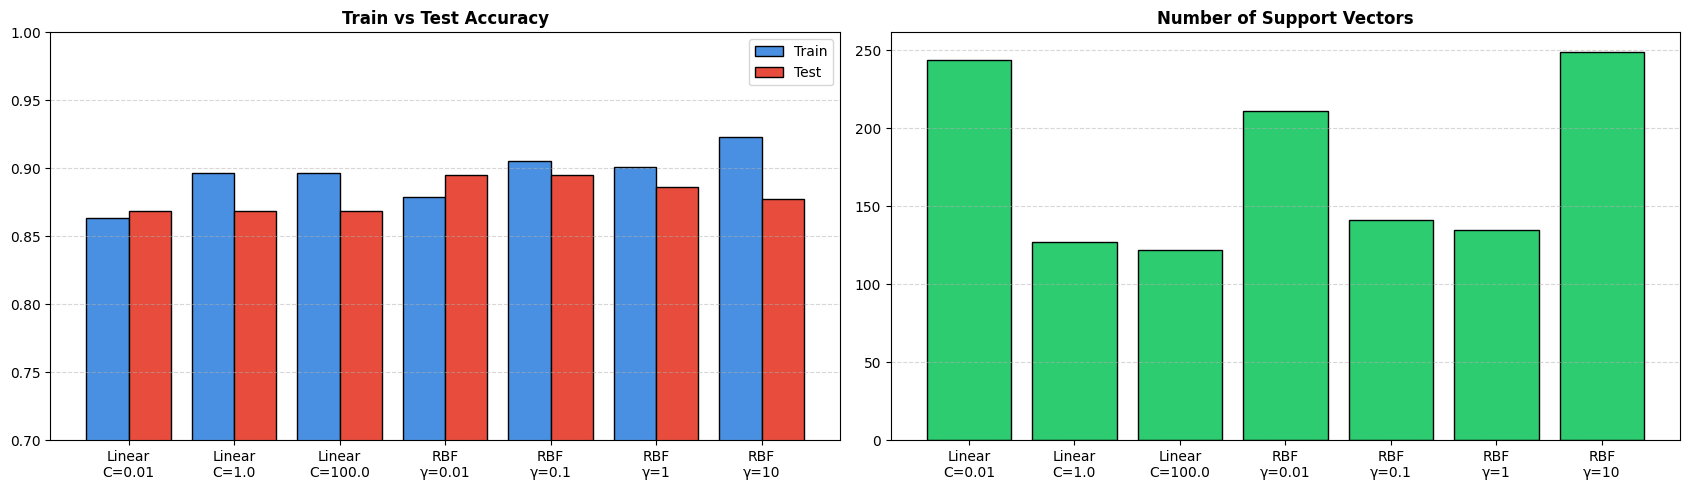

In [6]:
# build observation table from all trained models
observations = {
    ('Linear', 0.01): 'Wide margin / simple boundary',
    ('Linear', 1): 'Moderate fit',
    ('Linear', 100): 'Stricter classification',
    ('RBF', 0.01): 'Very smooth boundary',
    ('RBF', 0.1): 'More flexible',
    ('RBF', 1): 'Highly flexible',
    ('RBF', 10): 'Potential overfitting',
}
df_results = pd.DataFrame(results)
df_results['Gap (Train - Test)'] = df_results['Train Accuracy'] - df_results['Test Accuracy']
df_results['Observation'] = [observations[(k, c if k == 'Linear' else g)]
                             for k, c, g in zip(df_results['Kernel'], df_results['C'], df_results['Gamma'])]
print('=== OBSERVATION TABLE ===')
print(df_results.drop(columns='Margin Width').round(4).to_string(index=False))

# plot train vs test accuracy and support vector count
labels = [f'{k}\nC={c}' if k == 'Linear' else f'{k}\nγ={g}' for k, c, g in zip(df_results['Kernel'], df_results['C'], df_results['Gamma'])]
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].bar(x - 0.2, df_results['Train Accuracy'], 0.4, label='Train', color='#4a90e2', edgecolor='black')
axes[0].bar(x + 0.2, df_results['Test Accuracy'], 0.4, label='Test', color='#e74c3c', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title('Train vs Test Accuracy', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(x, df_results['No. of Support Vectors'], color='#2ecc71', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title('Number of Support Vectors', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**7. Selecting the Best Kernel & Hyperparameters with Cross-Validation (Step 15)**

* Training accuracy alone rewards overfitting, so the final configuration is chosen with **5-fold stratified cross-validation** on the training set only.
* `GridSearchCV` searches over both kernels, $C \in \{0.01, 0.1, 1, 10, 100\}$ and $\gamma \in \{0.01, 0.1, 1, 10\}$.
* A `Pipeline` (scaler → SVC) ensures the scaler is re-fit inside each CV fold, preventing leakage.

=== TOP 5 CONFIGURATIONS (5-FOLD CV) ===
Kernel     C  Gamma  CV Accuracy Mean  CV Accuracy Std
   rbf   1.0   0.10            0.9055           0.0358
   rbf  10.0   0.01            0.9033           0.0402
   rbf 100.0   0.01            0.9011           0.0348
linear  10.0    NaN            0.9011           0.0423
linear 100.0    NaN            0.8989           0.0453

best parameters : {'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}
best cv accuracy: 0.9055
test accuracy   : 0.8947

classification report:
              precision    recall  f1-score   support

   malignant       0.86      0.86      0.86        42
      benign       0.92      0.92      0.92        72

    accuracy                           0.89       114
   macro avg       0.89      0.89      0.89       114
weighted avg       0.89      0.89      0.89       114



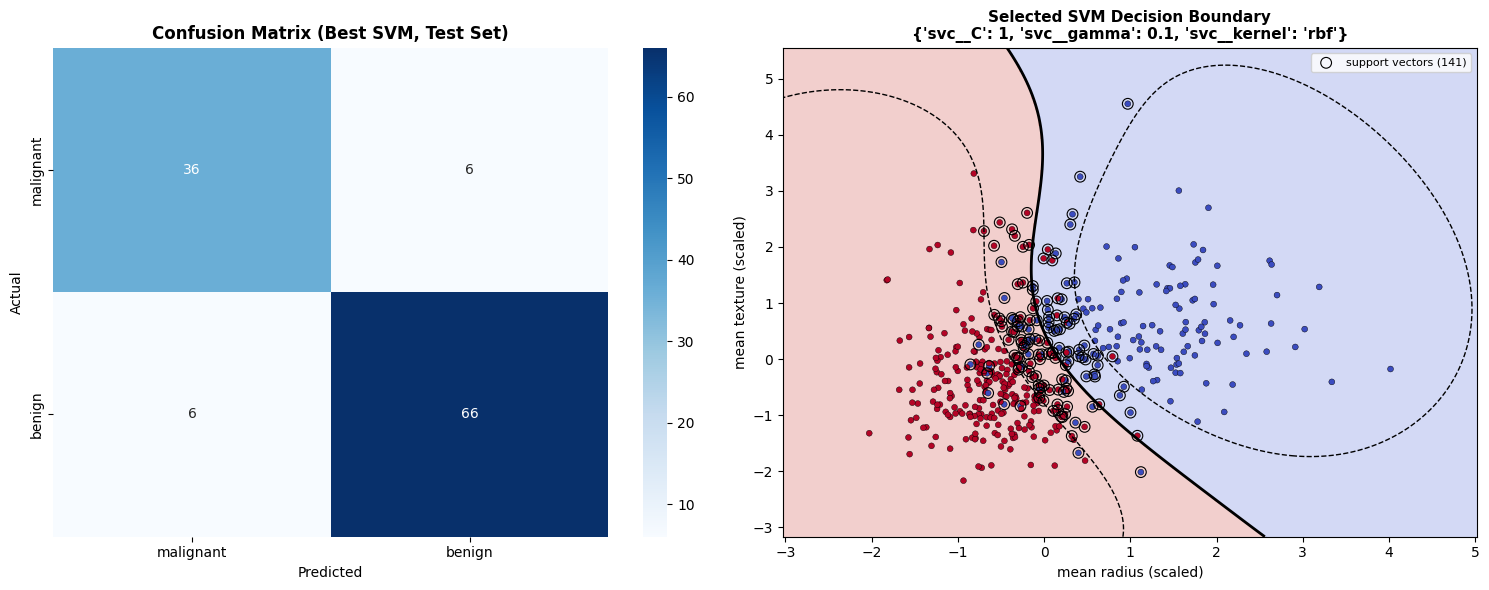

In [7]:
# grid search over kernel, c and gamma using 5-fold stratified cv
pipe = make_pipeline(StandardScaler(), SVC())
param_grid = [
    {'svc__kernel': ['linear'], 'svc__C': [0.01, 0.1, 1, 10, 100]},
    {'svc__kernel': ['rbf'], 'svc__C': [0.01, 0.1, 1, 10, 100], 'svc__gamma': [0.01, 0.1, 1, 10]},
]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)

# show top 5 configurations
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res = cv_res[['param_svc__kernel', 'param_svc__C', 'param_svc__gamma', 'mean_test_score', 'std_test_score']]
cv_res.columns = ['Kernel', 'C', 'Gamma', 'CV Accuracy Mean', 'CV Accuracy Std']
print('=== TOP 5 CONFIGURATIONS (5-FOLD CV) ===')
print(cv_res.sort_values('CV Accuracy Mean', ascending=False).head(5).round(4).to_string(index=False))

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(f'\nbest parameters : {grid_search.best_params_}')
print(f'best cv accuracy: {grid_search.best_score_:.4f}')
print(f'test accuracy   : {accuracy_score(y_test, y_pred):.4f}')
print('\nclassification report:')
print(classification_report(y_test, y_pred, target_names=data.target_names))

# confusion matrix and final decision boundary
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Best SVM, Test Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

best_svc = SVC(**{k.replace('svc__', ''): v for k, v in grid_search.best_params_.items()}).fit(X_train_s, y_train)
plot_boundary(best_svc, axes[1], f'Selected SVM Decision Boundary\n{grid_search.best_params_}')
plt.tight_layout()
plt.show()

### **Conclusion:**
* **Effect of $C$ (Linear SVM):** Increasing $C$ from 0.01 to 100 shrank the margin width (2.20 → 0.80) and the number of support vectors (244 → 122), and raised training accuracy (86.4% → 89.7%). Test accuracy stayed at 86.8% for every $C$, so a stricter margin did not help generalisation. $C = 0.01$ slightly underfits (lowest training accuracy).
* **Effect of $\gamma$ (RBF SVM, $C = 1$):** $\gamma = 0.01$ gave an almost linear, very smooth boundary. $\gamma = 0.1$ gave the best balance (train 90.6%, test 89.5%, gap ≈ 1%). At $\gamma = 10$ the boundary formed islands around individual points: training accuracy rose to 92.3% while test accuracy fell to 87.7%, and support vectors jumped to 249 — clear **overfitting**.
* **Linear vs Nonlinear:** With only `mean radius` and `mean texture`, the classes are nearly linearly separable, so the RBF kernel improves test accuracy only modestly over the linear kernel (89.5% vs 86.8%).
* **Final Model Selection:** 5-fold stratified cross-validation selected **RBF kernel, $C = 1$, $\gamma = 0.1$** (CV accuracy 90.55% ± 3.58%), which reached **89.47% test accuracy** (malignant recall 0.86, benign recall 0.92). The choice was based on CV evidence, not training accuracy.

In [8]:
# save the selected model for deployment
import joblib

joblib.dump(best_model, 'svm_breast_cancer_model.pkl')
loaded_model = joblib.load('svm_breast_cancer_model.pkl')
print('model saved and reloaded, test accuracy:', round(accuracy_score(y_test, loaded_model.predict(X_test)), 4))

model saved and reloaded, test accuracy: 0.8947


**8. Viva Questions & Comprehensive Answers**

### **Q1. What is the main objective of SVM?**
**Answer:** SVM finds the separating hyperplane that **maximises the margin** — the distance between the hyperplane and the nearest training points of either class. A larger margin gives better generalisation to unseen data. Formally it solves $\min \frac{1}{2}\lVert w \rVert^2$ subject to $y_i(w^T x_i + b) \ge 1$ (hard margin), or the soft-margin version with slack variables.

---

### **Q2. What are support vectors?**
**Answer:** Support vectors are the training points that lie **on or inside the margin** (or are misclassified). They are the only points with non-zero Lagrange multipliers ($\alpha_i > 0$), so the decision function $f(x) = \sum_i \alpha_i y_i K(x_i, x) + b$ depends only on them. Removing any other point leaves the boundary unchanged.

---

### **Q3. What is the margin in SVM?**
**Answer:** The margin is the width of the band around the decision boundary that contains no (hard margin) or few (soft margin) training points. For a linear SVM it equals $\frac{2}{\lVert w \rVert}$, the distance between the hyperplanes $w^T x + b = +1$ and $w^T x + b = -1$.

---

### **Q4. What does $C$ control?**
**Answer:** $C$ is the **regularisation parameter** that sets the trade-off between a wide margin and few training errors. It multiplies the total slack $\sum \xi_i$ in the objective: a high $C$ penalises margin violations heavily, a low $C$ tolerates them in exchange for a wider, simpler margin.

---

### **Q5. What happens when $C$ is very small?**
**Answer:** Margin violations become almost free, so the optimiser prefers a very **wide margin**. Many points fall inside the margin and become support vectors, the boundary becomes overly simple, and the model may **underfit**, as seen with $C = 0.01$ above.

---

### **Q6. What is the purpose of a kernel?**
**Answer:** A kernel computes the inner product of two points in a higher-dimensional feature space, $K(x, x') = \phi(x)^T \phi(x')$, **without explicitly computing $\phi$** (the *kernel trick*). This lets SVM learn nonlinear boundaries in the original space while still solving a linear problem in the transformed space. Common kernels: linear, polynomial, RBF, sigmoid.

---

### **Q7. What is the RBF kernel?**
**Answer:** The Radial Basis Function (Gaussian) kernel is $K(x, x') = \exp(-\gamma \lVert x - x' \rVert^2)$. It measures similarity that decays with distance, corresponds to an infinite-dimensional feature space, and can model highly nonlinear decision boundaries. It is the default kernel in scikit-learn's `SVC`.

---

### **Q8. What does gamma control in an RBF SVM?**
**Answer:** $\gamma$ controls **how far the influence of a single training point reaches**. Small $\gamma$ → wide Gaussian bumps, each point affects a large region, giving a smooth, nearly linear boundary (risk of underfitting). Large $\gamma$ → narrow bumps, each point affects only its immediate neighbourhood, giving a complex, curvy boundary.

---

### **Q9. What happens when gamma is extremely large?**
**Answer:** Each support vector's influence becomes so local that the boundary forms small islands around individual training points. Training accuracy rises towards 100% while test accuracy drops — classic **overfitting**.

---

### **Q10. Why should features be standardized before SVM?**
**Answer:** SVM relies on distances (margin width, and $\lVert x - x' \rVert$ in the RBF kernel). If one feature has a much larger range (e.g. `mean area` in hundreds vs `mean smoothness` below 1), it dominates those distances and the other features are effectively ignored. Standardisation puts all features on the same scale, makes $C$ and $\gamma$ meaningful across features, and also speeds up convergence of the solver.